In [1]:
import csv
def convert_residue_name(residue):
    # Dictionary mapping three-letter residue codes to one-letter codes
    residue_map = {
        'ASN': 'N',
        'GLY': 'G',
        'TYR': 'Y',
        'ASP': 'D',
        'SER': 'S',
        'ALA': 'A',
        'ARG': 'R',
        'CYS': 'C',
        'GLN': 'Q',
        'GLU': 'E',
        'HIS': 'H',
        'ILE': 'I',
        'LEU': 'L',
        'LYS': 'K',
        'MET': 'M',
        'PHE': 'F',
        'PRO': 'P',
        'HSD': 'H',
        'THR': 'T',
        'TRP': 'W',
        'VAL': 'V'
    }
    return residue_map.get(residue, residue)

def process_tsv(input_file, output_file):
    with open(input_file, 'r') as tsv_in, open(output_file, 'w', newline='') as tsv_out:
        reader = csv.reader(tsv_in, delimiter='\t')
        writer = csv.writer(tsv_out, delimiter='\t')
        
        for row in reader:
            # Apply find and replace operations
            row = [item.replace('A:', '') if item.startswith('A:') else item for item in row]
            row = [item.replace('B:', '') if item.startswith('B:') else item for item in row]
            row = [convert_residue_name(item.split(":")[0]) + item.split(":")[1] if ':' in item else item for item in row]
            writer.writerow(row)
input_file = '/Users/chenyifang/Desktop/RA/VMP1_ATG2/ATG2_only/R2/resfrequencies_2.tsv'
output_file = '/Users/chenyifang/Desktop/RA/VMP1_ATG2/ATG2_only/R2/converted_2.tsv'
process_tsv(input_file, output_file)



In [2]:
import pandas as pd
# Read the TSV file into a DataFrame
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv", delimiter="\t", skiprows=2)
df.columns = ['UNL', 'residue', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers
df_sorted = df.sort_values(by='residue_numbers')
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Write the sorted DataFrame back to a CSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/RA/RGX/R1/new.tsv", index=False)


In [40]:
import pandas as pd

# Read the TSV file into a DataFrame
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/averaged_contact_frequencies_last500.tsv", delimiter="\t")
df.columns = ['residue_1', 'lig', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue_1'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers
df_sorted = df.sort_values(by='residue_numbers')

# Drop the auxiliary column used for sorting
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Write the sorted DataFrame back to a CSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/RA/RGX/sorted_last500.tsv", index=False, sep='\t')

# Check the sorted DataFrame
print(df_sorted)


   residue_1     lig  frequency
0        F68  Lig601   0.808333
1       AL69  Lig601   0.899000
7        G71  Lig601   0.944000
4        L72  Lig601   0.991333
12       G73  Lig601   1.000000
16       N74  Lig601   0.849333
11      C144  Lig601   0.685333
6       N145  Lig601   0.985333
9       Y148  Lig601   1.000000
3       F314  Lig601   0.904667
5       F315  Lig601   1.000000
2       S316  Lig601   0.892000
14     AL318  Lig601   0.193667
10      I319  Lig601   0.945333
13      L321  Lig601   0.629333
15      S417  Lig601   0.962667
8       Q418  Lig601   0.979333


In [18]:
import csv
def convert_residue_name(residue):
    # Dictionary mapping three-letter residue codes to one-letter codes
    residue_map = {
        'ASN': 'N',
        'UNL': 'Lig',
        'GLY': 'G',
        'TYR': 'Y',
        'ASP': 'D',
        'SER': 'S',
        'ALA': 'A',
        'ARG': 'R',
        'CYS': 'C',
        'GLN': 'Q',
        'GLU': 'E',
        'HIS': 'H',
        'ILE': 'I',
        'LEU': 'L',
        'LYS': 'K',
        'MET': 'M',
        'PHE': 'F',
        'PRO': 'P',
        'THR': 'T',
        'TRP': 'W',
        'VAL': 'V'
    }
    return residue_map.get(residue, residue)

def process_tsv(input_file, output_file):
    with open(input_file, 'r') as tsv_in, open(output_file, 'w', newline='') as tsv_out:
        reader = csv.reader(tsv_in, delimiter='\t')
        writer = csv.writer(tsv_out, delimiter='\t')
        
        # Skip the first two rows
        next(reader)  # Skip the first row
        next(reader)  # Skip the second row
        
        for row in reader:
            # Apply find and replace operations
            row = [item.replace('A:', '') if item.startswith('A:') else item for item in row]
            row = [item.replace('B:', '') if item.startswith('B:') else item for item in row]
            row = [convert_residue_name(item.split(":")[0]) + item.split(":")[1] if ':' in item else item for item in row]
            writer.writerow(row)

input_file = '/Users/chenyifang/Desktop/RA/GAA/md/R3/resfrequencies_3_last500.tsv'
output_file = '/Users/chenyifang/Desktop/RA/GAA/md/R3/resfrequencies_3_last500_converted.tsv'
process_tsv(input_file, output_file)


In [40]:
import pandas as pd

# Read the TSV file into a DataFrame
df = pd.read_csv("/Users/chenyifang/Desktop/RA/SLC6A8/R1/frequency_1_converted.tsv", delimiter="\t", skiprows=2)

# Print the first few rows of the DataFrame
print(df.head())

   Lig601   N74  0.975
0  Lig601   G73  1.000
1  Lig601  Y148  0.006
2  Lig601  D416  0.734
3  Lig601  S417  0.998
4  Lig601   G71  0.927


In [8]:
import pandas as pd

# Read the TSV file while skipping the first few lines
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv", delimiter="\t", skiprows=3, header=None)

# Set the correct column names manually
df.columns = ['residue', 'ligand', 'frequency']

# Display the first few rows to verify
print(df.head())


  residue      ligand  frequency
0     L72      Lig601      0.986
1    S316      Lig601      0.893
2    S417      Lig601      0.954
3     G71      Lig601      0.956
4    C144      Lig601      0.918


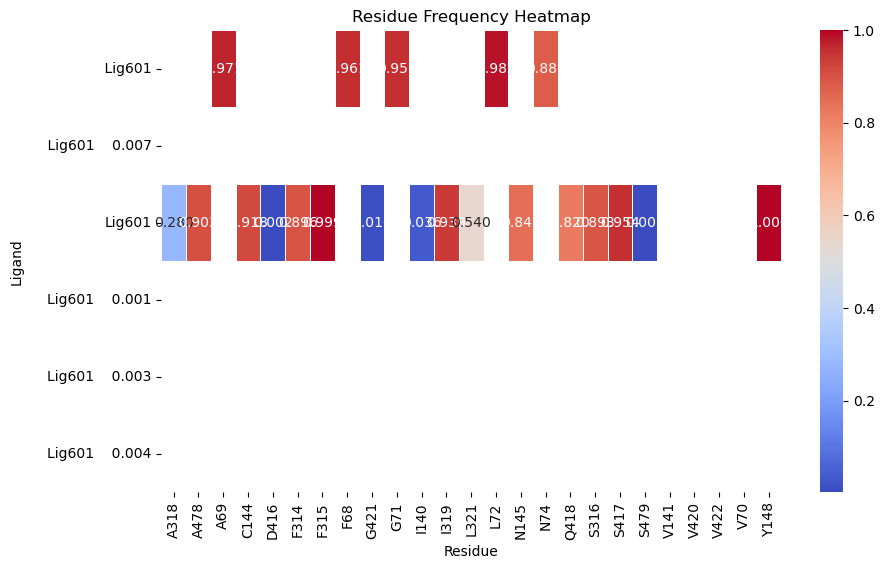

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file while skipping the first few lines
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv", delimiter="\t", skiprows=3, header=None)

# Set the correct column names manually
df.columns = ['residue', 'ligand', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers to maintain original order
df_sorted = df.sort_values(by='residue_numbers')

# Drop the auxiliary column used for sorting
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Create a pivot table from the sorted DataFrame
pivot_df = df_sorted.pivot(index='ligand', columns='residue', values='frequency')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, cmap='coolwarm', annot=True, fmt=".3f", linewidths=.5)
plt.title('Residue Frequency Heatmap')
plt.xlabel('Residue')
plt.ylabel('Ligand')
plt.show()


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file while skipping the first few lines
df = pd.read_csv("/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/aggregated_frequencies.tsv", delimiter="\t", skiprows=3, header=None)

# Set the correct column names manually
df.columns = ['residue', 'ligand', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers to maintain original order
df_sorted = df.sort_values(by='residue_numbers')

# Drop the auxiliary column used for sorting
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Save the sorted DataFrame to a new TSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/sorted_frequencies.tsv", sep='\t', index=False)



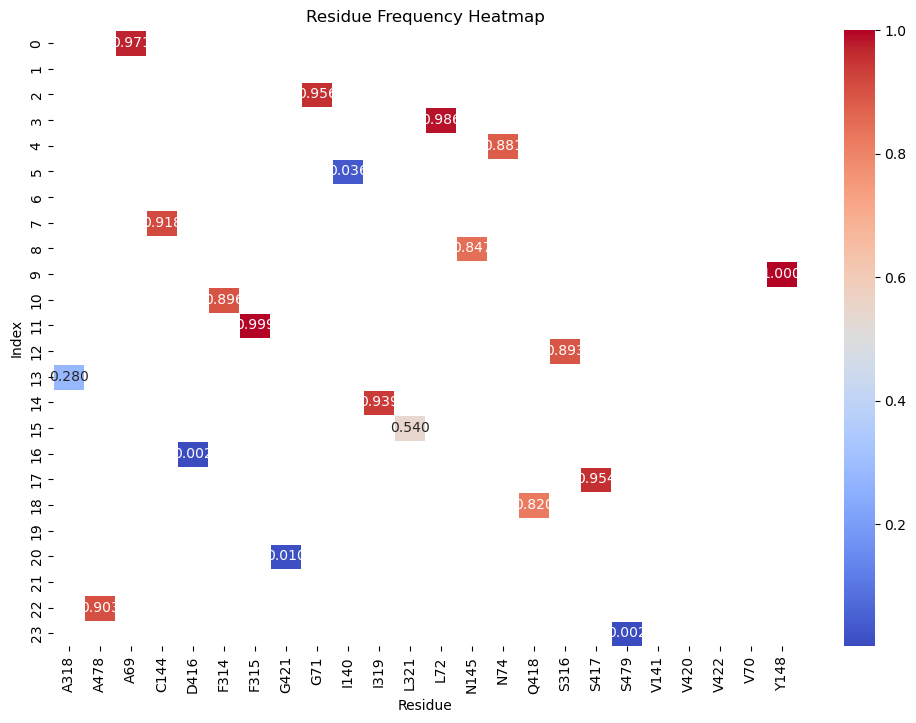

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file into a DataFrame
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/R1/sorted_frequency.tsv", delimiter="\t", skiprows=1)
df.columns = ['residue', 'ligand', 'frequency']

# Add an index column to keep the current order
df['index'] = df.index

# Create a pivot table from the DataFrame, keeping the original order
pivot_df = df.pivot(index='index', columns='residue', values='frequency')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='coolwarm', annot=True, fmt=".3f", linewidths=.5)
plt.title('Residue Frequency Heatmap')
plt.xlabel('Residue')
plt.ylabel('Index')
plt.show()

# Save the DataFrame with the added index to a new TSV file
df.to_csv("/Users/chenyifang/Desktop/RA/RGX/R1/sorted_frequency_with_index.tsv", sep='\t', index=False)


In [20]:
import pandas as pd

# Read the TSV file while skipping the first few lines
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv", delimiter="\t", skiprows=2, header=None)

# Set the correct column names manually
df.columns = ['residue', 'ligand', 'frequency']

# Function to extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers to maintain original order
df_sorted = df.sort_values(by='residue_numbers')

# Add an index column to keep the current order
df_sorted.reset_index(drop=True, inplace=True)
df_sorted['index'] = df_sorted.index

# Drop the auxiliary column used for sorting
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Save the sorted DataFrame with the added index to a new TSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/RA/RGX/R1/sorted_frequency_with_index.tsv", sep='\t', index=False)


In [42]:
import csv
def convert_residue_name(residue):
    # Dictionary mapping three-letter residue codes to one-letter codes
    residue_map = {
        'ASN': 'N',
        'UNL': 'Lig',
        'GLY': 'G',
        'TYR': 'Y',
        'ASP': 'D',
        'SER': 'S',
        'ALA': 'A',
        'ARG': 'R',
        'CYS': 'C',
        'GLN': 'Q',
        'GLU': 'E',
        'HIS': 'H',
        'ILE': 'I',
        'LEU': 'L',
        'LYS': 'K',
        'MET': 'M',
        'PHE': 'F',
        'PRO': 'P',
        'THR': 'T',
        'TRP': 'W',
        'VAL': 'V'
    }
    return residue_map.get(residue, residue)

def process_tsv(input_file, output_file):
    with open(input_file, 'r') as tsv_in, open(output_file, 'w', newline='') as tsv_out:
        reader = csv.reader(tsv_in, delimiter='\t')
        writer = csv.writer(tsv_out, delimiter='\t')
        
        # Skip the first two rows
        next(reader)  # Skip the first row
        next(reader)  # Skip the second row
        
        for row in reader:
            # Apply find and replace operations
            row = [item.replace('X:', '') if item.startswith('X:') else item for item in row]
            row = [item.replace('UNL:', 'Lig:') if item.startswith('UNL:') else item for item in row]
            row = [convert_residue_name(item.split(":")[0]) + item.split(":")[1] if ':' in item else item for item in row]
            writer.writerow(row)

input_file = '/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1.tsv'
output_file = '/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv'
process_tsv(input_file, output_file)

#plotting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file into a DataFrame with explicit column names
file_path = '/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv'
column_names = ['residue', 'ligand', 'contact_frequency']
df = pd.read_csv(file_path, delimiter='\t', names=column_names)

# Pivot the DataFrame for heatmap plotting
pivot_data = df.pivot(index='ligand', columns='residue', values='contact_frequency')

# Plot heatmap
plt.figure(figsize=(15, 1))
sns.heatmap(pivot_data, cmap="Blues", annot=False)
plt.xticks(rotation=45)
plt.xlabel('Residue')
plt.ylabel('Ligand')
plt.title('Contact Frequency Heatmap')
plt.show()

###reorder the residues based on the id
import pandas as pd
# Read the TSV file into a DataFrame
df = pd.read_csv("/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv", delimiter="\t", skiprows=2)
df.columns = ['Lig', 'residue', 'frequency']

# extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers
df_sorted = df.sort_values(by='residue_numbers')
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Write the sorted DataFrame back to a CSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/RA/RGX/R1/new.csv", index=False)

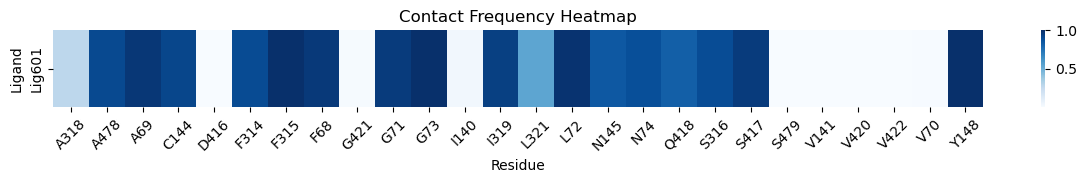

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file into a DataFrame with explicit column names
file_path = '/Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv'
column_names = ['residue', 'ligand', 'contact_frequency']
df = pd.read_csv(file_path, delimiter='\t', names=column_names)

# Pivot the DataFrame for heatmap plotting
pivot_data = df.pivot(index='ligand', columns='residue', values='contact_frequency')

# Plot heatmap
plt.figure(figsize=(15, 1))
sns.heatmap(pivot_data, cmap="Blues", annot=False)
plt.xticks(rotation=45)
plt.xlabel('Residue')
plt.ylabel('Ligand')
plt.title('Contact Frequency Heatmap')
plt.show()


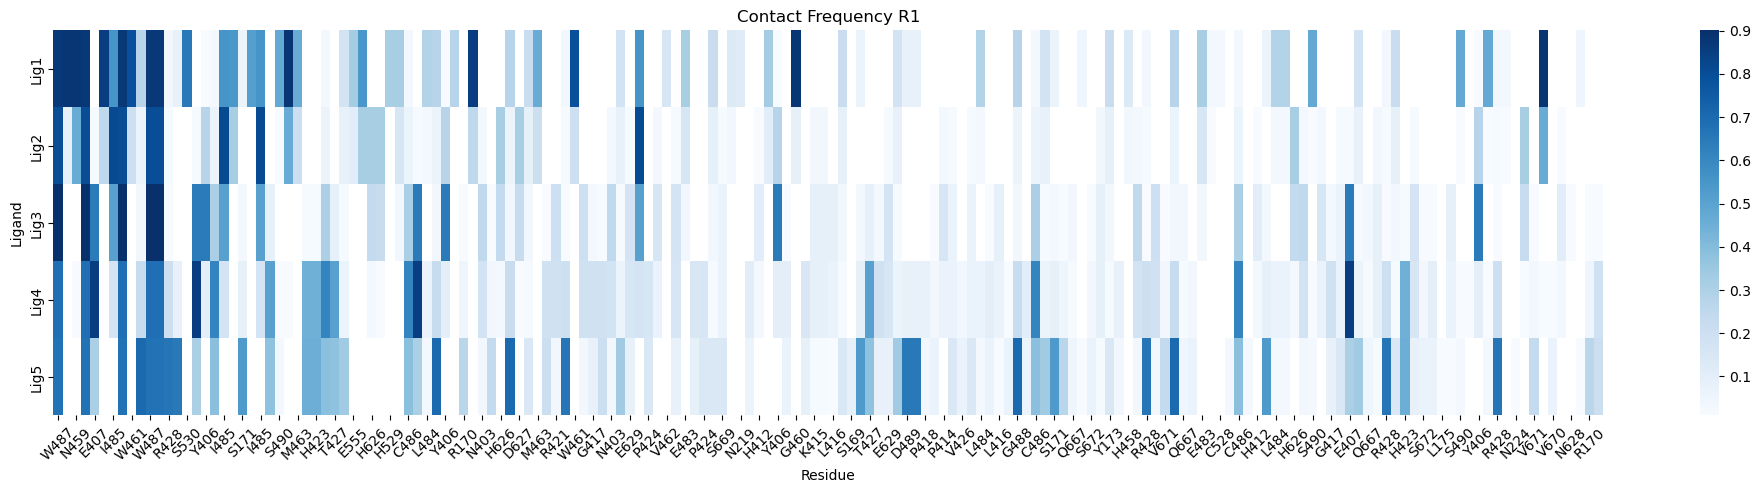

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/R1/converted_1.tsv'


# Read the TSV file into a DataFrame
df = pd.read_csv(file_path, sep='\t', header=None, skiprows=2, names=['residue_1', 'residue_2', 'Frequency'])

# Aggregate duplicate entries by summing their frequencies
df_aggregated = df.groupby(['residue_1', 'residue_2'], as_index=False).sum()

# Save the aggregated DataFrame to a new TSV file
df_aggregated.to_csv(output_file_path, sep='\t', index=False)

# Sort the DataFrame by the 'Frequency' column in descending order
df_sorted = df_aggregated.sort_values(by='Frequency', ascending=False)

# To ensure the correct order of residues, set the order of columns manually based on sorted DataFrame
residues_order = df_sorted['Residue'].tolist()

# Pivot the DataFrame for heatmap
heatmap_data = df_aggregated.pivot(index='Ligand', columns='Residue', values='Frequency')
heatmap_data = heatmap_data[residues_order]

# Plotting the heatmap
plt.figure(figsize=(25, 5))
sns.heatmap(heatmap_data, cmap='Blues', annot=False)
plt.xticks(rotation=45)
plt.title('Contact Frequency R1')

# Save the heatmap to a PNG file
plt.savefig(heatmap_output_path, format='png', dpi=1200)

plt.show()

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/test_3.tsv'
output_file_path = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/test_add_3.tsv'

# Read the TSV file into a DataFrame
df = pd.read_csv(file_path, sep='\t', skiprows=2, header=None, names=['residue_1', 'residue_2', 'Frequency'])

# Aggregate duplicate entries by summing their frequencies
df_aggregated = df.groupby(['residue_1', 'residue_2'], as_index=False).sum()

# Save the aggregated DataFrame to a new TSV file
df_aggregated.to_csv(output_file_path, sep='\t', index=False)

# Sort the DataFrame by the 'Frequency' column in descending order
df_sorted = df_aggregated.sort_values(by='Frequency', ascending=False)

# To ensure the correct order of residues, set the order of columns manually based on sorted DataFrame
residues_order = df_sorted['residue_1'].tolist()

# Pivot the DataFrame for heatmap
heatmap_data = df_aggregated.pivot(index='residue_1', columns='residue_2', values='Frequency')
heatmap_data = heatmap_data[residues_order]

# Define a fixed color range
vmin = 0  # Minimum value for the color range
vmax = 3  # Maximum value for the color range

# Plotting the heatmap with fixed color range
plt.figure(figsize=(40, 15))
sns.heatmap(heatmap_data, cmap='Blues', annot=False, vmin=vmin, vmax=vmax)
plt.xticks(rotation=45)
plt.title('Contact Frequency R1')

# Save the heatmap to a PNG file
#plt.savefig('/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/R1/R1_contacts.png', dpi=300, bbox_inches='tight')
plt.show()


KeyError: "None of [Index(['F557', 'W461', 'H529', 'T558', 'W487', 'G559', 'M581', 'Y596', 'R578',\n       'N527', 'D564', 'I485', 'S530', 'E561', 'P467', 'L592', 'H423', 'L556',\n       'R595', 'Y173', 'D526', 'K422', 'E555', 'E579', 'S582', 'S560', 'M463',\n       'D627', 'I616', 'AL580', 'I577', 'P424', 'C486', 'Y584', 'S174', 'E588',\n       'AL583'],\n      dtype='object', name='residue_2')] are in the [columns]"

In [4]:
import csv

def convert_residue_name(residue):
    # Dictionary mapping three-letter residue codes to one-letter codes
    residue_map = {
        'ASN': 'N',
        'AGLC': 'Lig',
        'GLY': 'G',
        'TYR': 'Y',
        'ASP': 'D',
        'SER': 'S',
        'ALA': 'A',
        'ARG': 'R',
        'CYS': 'C',
        'GLN': 'Q',
        'GLU': 'E',
        'HIS': 'H',
        'ILE': 'I',
        'LEU': 'L',
        'LYS': 'K',
        'MET': 'M',
        'PHE': 'F',
        'PRO': 'P',
        'HSD': 'H',
        'THR': 'T',
        'TRP': 'W',
        'VAL': 'V'
    }
    return residue_map.get(residue, residue)

def process_tsv(input_file, output_file):
    with open(input_file, 'r') as tsv_in, open(output_file, 'w', newline='') as tsv_out:
        reader = csv.reader(tsv_in, delimiter='\t')
        writer = csv.writer(tsv_out, delimiter='\t')
        
        for row in reader:
            # Apply find and replace operations
            new_row = []
            for item in row:
                if item.startswith('A:'):
                    item = item.replace('A:', '')
                elif item.startswith('B:AGLC:'):
                    item = item.replace('B:AGLC:', 'Lig:')
                if ':' in item:
                    parts = item.split(":")
                    residue = convert_residue_name(parts[0])
                    new_item = residue + "".join(parts[1:])
                    new_row.append(new_item)
                else:
                    new_row.append(item)
            writer.writerow(new_row)

input_file = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/resfrequencies_SOLU3.tsv'
output_file = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/new_converted_3.tsv'
process_tsv(input_file, output_file)


In [13]:
import csv

def replace_second_column_with_glc(input_file, output_file):
    with open(input_file, 'r') as tsv_in, open(output_file, 'w', newline='') as tsv_out:
        reader = csv.reader(tsv_in, delimiter='\t')
        writer = csv.writer(tsv_out, delimiter='\t')
        
        for row in reader:
            # Replace the second column with 'GLC'
            if len(row) > 1:
                row[1] = 'GLC'
            writer.writerow(row)

input_file = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/new_converted_3.tsv'
output_file = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/test_3.tsv'
replace_second_column_with_glc(input_file, output_file)


In [6]:
import csv
def convert_residue_name(residue):
    # Dictionary mapping three-letter residue codes to one-letter codes
    residue_map = {
        'ASN': 'N',
        'OLE': 'Lig',
        'GLY': 'G',
        'TYR': 'Y',
        'ASP': 'D',
        'SER': 'S',
        'ALA': 'A',
        'ARG': 'R',
        'CYS': 'C',
        'GLN': 'Q',
        'GLU': 'E',
        'HIS': 'H',
        'ILE': 'I',
        'LEU': 'L',
        'LYS': 'K',
        'MET': 'M',
        'PHE': 'F',
        'PRO': 'P',
        'THR': 'T',
        'TRP': 'W',
        'VAL': 'V'
    }
    return residue_map.get(residue, residue)

def process_tsv(input_file, output_file):
    with open(input_file, 'r') as tsv_in, open(output_file, 'w', newline='') as tsv_out:
        reader = csv.reader(tsv_in, delimiter='\t')
        writer = csv.writer(tsv_out, delimiter='\t')
        
        # Skip the first two rows
        next(reader)  # Skip the first row
        next(reader)  # Skip the second row
        
        for row in reader:
            # Apply find and replace operations
            row = [item.replace('A:', '') if item.startswith('A:') else item for item in row]
            row = [item.replace('B:', '') if item.startswith('B:') else item for item in row]
            row = [convert_residue_name(item.split(":")[0]) + item.split(":")[1] if ':' in item else item for item in row]
            writer.writerow(row)

input_file = '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_OA/RUN4/frequencies_4.tsv'
output_file = '/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_OA/RUN4/frequency_4_converted.tsv'
process_tsv(input_file, output_file)


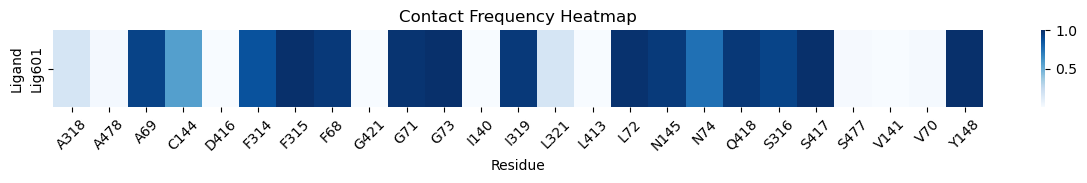

In [7]:
#plotting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file into a DataFrame with explicit column names
file_path = '/Users/chenyifang/Desktop/RA/GAA/md/R2/frequency_2_converted.tsv'
column_names = ['residue', 'ligand', 'contact_frequency']
df = pd.read_csv(file_path, delimiter='\t', names=column_names)

# Pivot the DataFrame for heatmap plotting
pivot_data = df.pivot(index='ligand', columns='residue', values='contact_frequency')

# Plot heatmap
plt.figure(figsize=(15, 1))
sns.heatmap(pivot_data, cmap="Blues", annot=False)
plt.xticks(rotation=45)
plt.xlabel('Residue')
plt.ylabel('Ligand')
plt.title('Contact Frequency Heatmap')
plt.show()

###reorder the residues based on the id
import pandas as pd
# Read the TSV file into a DataFrame
df = pd.read_csv("/Users/chenyifang/Desktop/RA/GAA/md/R2/frequency_2_converted.tsv", delimiter="\t", skiprows=2)
df.columns = ['Lig', 'residue', 'frequency']

# extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers
df_sorted = df.sort_values(by='residue_numbers')
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Write the sorted DataFrame back to a CSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/RA/GAA/md/R2/new.csv", index=False)

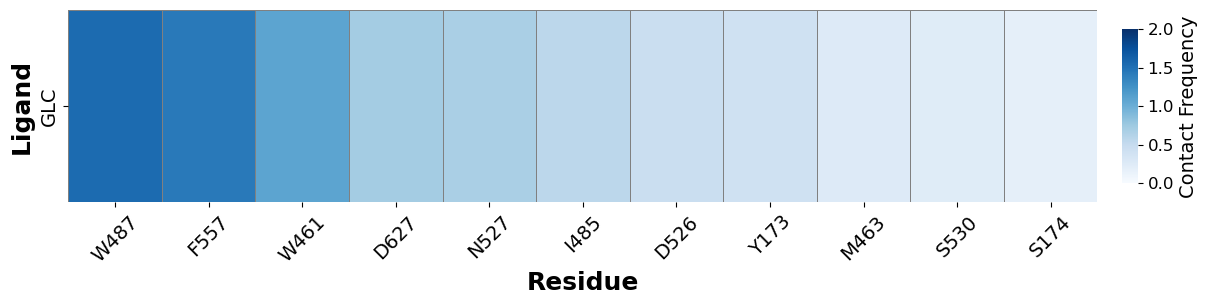

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the parameters
file_path = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/new_average_frequency.tsv'
x_axis_title = 'Residue'
y_axis_title = 'Ligand'
#plot_title = 'A'
color_min = 0  # Set the minimum value for the color bar, None for default
color_max = 2.0  # Set the maximum value for the color bar, None for default

# Read the TSV file into a DataFrame
df = pd.read_csv(file_path, sep='\t', skiprows=1, header=None, names=['Residue', 'Ligand', 'Frequency'])

# Debugging: Print first few rows to check the data
#print(df.head())

# Sort the DataFrame by the 'Frequency' column in descending order
df_sorted = df.sort_values(by='Frequency', ascending=False)

# To ensure the correct order of residues, set the order of columns manually based on sorted DataFrame
residues_order = df_sorted['Residue'].tolist()

# Pivot the DataFrame for heatmap
heatmap_data = df_sorted.pivot(index='Ligand', columns='Residue', values='Frequency')
heatmap_data = heatmap_data[residues_order]

# Plotting the heatmap
plt.figure(figsize=(16, 2.5))
ax = sns.heatmap(heatmap_data, cmap='Blues', annot=False, vmin=color_min, vmax=color_max, cbar_kws={
        'label': 'Contact Frequency',
        'aspect': 10,
        'pad': 0.02,
        'shrink': 0.8,
        'format': "%.1f",
    },
    linewidths=0.5,  
    linecolor='gray'
)

# Adjust font sizes and other properties
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(x_axis_title, fontsize=18, weight='bold')
plt.ylabel(y_axis_title, fontsize=18, weight='bold')
#plt.title(plot_title, fontsize=20, weight='bold', pad=15)

# Adjust color bar label fontsize
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(14)  # Color bar label fontsize
cbar.ax.tick_params(labelsize=12)  # Color bar ticks fontsize

# Save the plot
plt.savefig('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/Average_500_contacts.pdf', dpi=600, bbox_inches='tight')

plt.show()




In [17]:
###reorder the residues based on the id
import pandas as pd
# Read the TSV file while skipping the first few lines
df = pd.read_csv("/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_OA/RUN3/frequency_4_converted.tsv", delimiter="\t", header=None)

df.columns = ['residue', 'ligand', 'frequency']

# extract residue numbers from a string
def extract_residue_number(string):
    numbers = ''.join(filter(str.isdigit, string))
    return int(numbers) if numbers else 0

# Extract residue numbers from the 'residue' column
df['residue_numbers'] = df['residue'].apply(extract_residue_number)

# Sort the DataFrame by residue_numbers
df_sorted = df.sort_values(by='residue_numbers')
df_sorted.drop(columns=['residue_numbers'], inplace=True)

# Write the sorted DataFrame back to a CSV file
df_sorted.to_csv("/Users/chenyifang/Desktop/PPAR_DHA_OA_trjs/PPAR_LBD_OA/RUN4/new.csv", index=False)

In [35]:
import pandas as pd

# Define the paths to your CSV files
csv_files = [
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/test_add_1.tsv',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/test_add_2.tsv',
    '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/test_add_3.tsv'
]

# Read all CSV files into a list of dataframes and specify the correct separator
dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep='\t')
    dfs.append(df)
    print(f"Columns in {f}: {df.columns.tolist()}")

# Assuming the columns are now correctly named, we can proceed with the rest of the script
common_residues = set(dfs[0]['residue_1'])
for df in dfs[1:]:
    common_residues.intersection_update(df['residue_1'])

# Filter dataframes to include only common residues
filtered_dfs = [df[df['residue_1'].isin(common_residues)] for df in dfs]

# Merge dataframes on 'residue' and 'ligand'
merged_df = pd.concat(filtered_dfs).groupby(['residue_1', 'residue_2']).mean().reset_index()

output_file = '/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/new_average_frequency.tsv'
merged_df.to_csv(output_file, sep='\t', index=False)


Columns in /Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R1/test_add_1.tsv: ['residue_1', 'residue_2', 'Frequency']
Columns in /Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R2/test_add_2.tsv: ['residue_1', 'residue_2', 'Frequency']
Columns in /Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/R3/test_add_3.tsv: ['residue_1', 'residue_2', 'Frequency']


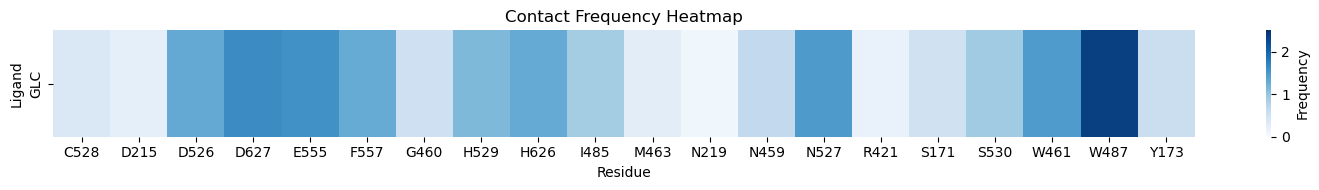

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from CSV
data = pd.read_csv('/Users/chenyifang/Desktop/RA/GDE/md/restraint/Pos_Dis/average_sorted_frequency.csv')

# Pivot the data to prepare for heatmap
heatmap_data = data.pivot(index='ligand', columns='residue', values='frequency')

# Set up the heatmap using seaborn with vmin and vmax
plt.figure(figsize=(15, 2))
sns.heatmap(heatmap_data, cmap='Blues', vmin=0.0, vmax=2.5, annot=False, fmt='.2f', cbar_kws={'label': 'Frequency'})

# Customize labels and title
plt.xlabel('Residue')
plt.ylabel('Ligand')
plt.title('Contact Frequency Heatmap')

# Show plot
plt.tight_layout()
plt.show()


Top 10 contact pairs with highest contact frequency:
   residue_1 residue_2  contact_frequency
39       Y19   POPE308              0.715
10      L140   POPE308              0.669
0       P141   POPE308              0.639
14      C135   POPE308              0.590
17       R15   POPE308              0.582
8        V12   POPE308              0.556
13      L136   POPE308              0.506
12      F156   POPE308              0.471
9       L153   POPE308              0.454
34     AL132   POPE308              0.438


/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_3144/3710259294.py:14: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = data.pivot('residue_2', 'residue_1', 'contact_frequency')


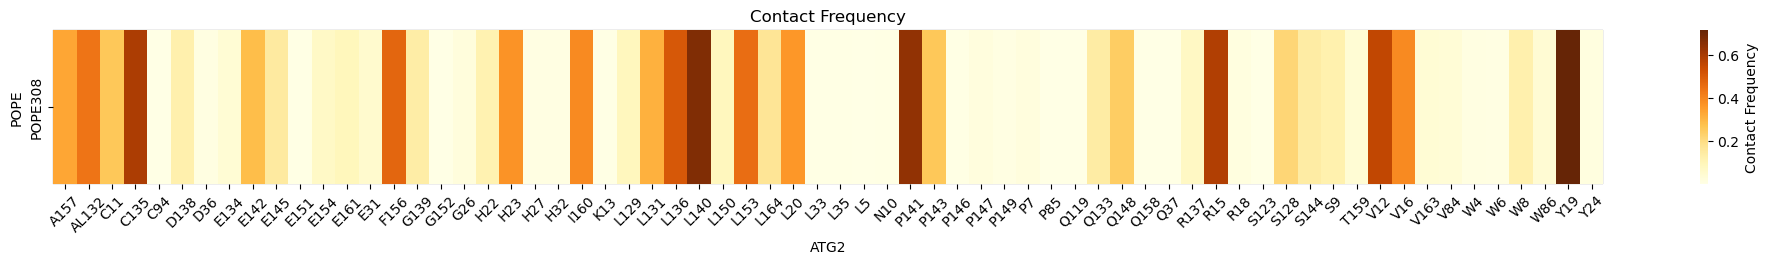

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file
data = pd.read_csv('/Users/chenyifang/Desktop/RA/VMP1_ATG2/ATG2_only/R2/converted_2.tsv', sep='\t', comment='#', names=['residue_1', 'residue_2', 'contact_frequency'])

#Print the top 10 contact pairs with the highest contact frequency
top_10_contacts = data.nlargest(10, 'contact_frequency')
print("Top 10 contact pairs with highest contact frequency:")
print(top_10_contacts)

# Pivot the DataFrame to get the format needed for a heatmap
heatmap_data = data.pivot('residue_2', 'residue_1', 'contact_frequency')

# Plot the heatmap
plt.figure(figsize=(25, 2))
ax = sns.heatmap(heatmap_data, cmap='YlOrBr', annot=False, fmt=".3f", cbar_kws={'label': 'Contact Frequency'})
plt.title('Contact Frequency')
plt.xticks(rotation=45)
plt.xlabel('ATG2')
plt.ylabel('POPE')

# Add an outline around the heatmap
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(0.1)
plt.savefig('/Users/chenyifang/Desktop/RA/VMP1_ATG2/ATG2_only/R2/contacts_2.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
import pandas as pd
from functools import reduce

# Function to read a TSV file and process it into a DataFrame
def read_tsv(file_path):
    df = pd.read_csv(file_path, sep='\t', comment='#', header=None)
    df.columns = ['residue_1', 'residue_2', 'contact_frequency']
    return df

# Paths to your TSV files
file_paths = ['/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/R1/converted_1_POPE_ATG2.tsv', '/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/R3/converted_3_POPE_ATG2.tsv']

# Read and store dataframes
dfs = [read_tsv(file) for file in file_paths]

# Merge dataframes on 'residue_1' and 'residue_2'
merged_df = reduce(lambda left, right: pd.merge(left, right, on=['residue_1', 'residue_2'], how='inner'), dfs)

# Calculate the average contact frequency
merged_df['average_contact_frequency'] = merged_df.iloc[:, 2:].mean(axis=1)

# Select necessary columns
result_df = merged_df[['residue_1', 'residue_2', 'average_contact_frequency']]

# Save to a new TSV file
result_df.to_csv('/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/averaged_contact_frequencies_POPE_ATG2.csv', index=False)
print("Averaged contact frequencies have been saved to 'averaged_contact_frequencies.tsv'")


Averaged contact frequencies have been saved to 'averaged_contact_frequencies.tsv'


Top 10 contact pairs with highest contact frequency:
   residue_1 residue_2  average_contact_frequency
1        R15   POPE407                     0.9510
2        Y19   POPE407                     0.8220
3       P141   POPE407                     0.7940
4       A132   POPE407                     0.7135
5       E142   POPE407                     0.6890
6       S144   POPE407                     0.6825
7       C135   POPE407                     0.6530
8       L140   POPE407                     0.6370
9        C11   POPE407                     0.6310
10      F156   POPE407                     0.6110


/var/folders/6g/sb2r7d4n379gcm6jc9q5njlr0000gn/T/ipykernel_3144/2528598445.py:20: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data = data.pivot('residue_2', 'residue_1', 'average_contact_frequency')


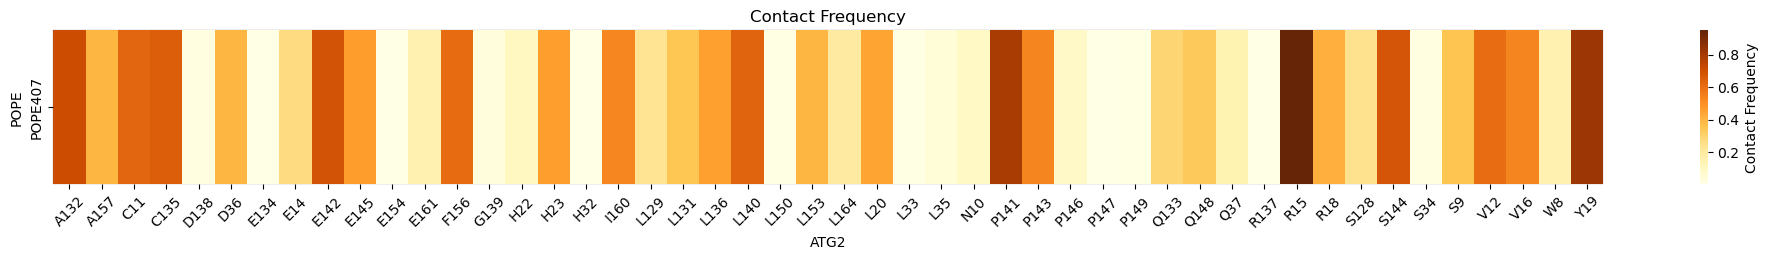

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the TSV file
data = pd.read_csv('/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/averaged_sorted_contact_frequencies_POPE_ATG2.csv', sep=',', comment='#', names=['residue_1', 'residue_2', 'average_contact_frequency'])

# Convert 'contact_frequency' to numeric type
data['average_contact_frequency'] = pd.to_numeric(data['average_contact_frequency'], errors='coerce')

# Drop rows with NaN values in 'contact_frequency'
data = data.dropna(subset=['average_contact_frequency'])

# Print the top 10 contact pairs with the highest contact frequency
top_10_contacts = data.nlargest(10, 'average_contact_frequency')
print("Top 10 contact pairs with highest contact frequency:")
print(top_10_contacts)

# Pivot the DataFrame to get the format needed for a heatmap
heatmap_data = data.pivot('residue_2', 'residue_1', 'average_contact_frequency')

# Plot the heatmap
plt.figure(figsize=(25, 2))
ax = sns.heatmap(heatmap_data, cmap='YlOrBr', annot=False, fmt=".3f", cbar_kws={'label': 'Contact Frequency'})
plt.title('Contact Frequency')
plt.xticks(rotation=45)
plt.xlabel('ATG2')
plt.ylabel('POPE')

# Add an outline around the heatmap
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(0.1)
plt.savefig('/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/POPE_average_contacts.png', dpi=300, bbox_inches='tight')
plt.show()


In [28]:
#####calculate the average value when the residue appears in each repeat; otherwise, delete it#######
import pandas as pd

# Define the paths to your CSV files
csv_files = [
    '/Users/chenyifang/Desktop/RA/RGX/R1/resfrequencies_2_last500_converted.tsv',
    '/Users/chenyifang/Desktop/RA/RGX/R2/resfrequencies_2_last500_converted.tsv',
    '/Users/chenyifang/Desktop/RA/RGX/R3/resfrequencies_2_last500_converted.tsv'
]

# Read all CSV files into a list of dataframes and specify the correct separator
dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep='\t', comment='#', header=None)
    dfs.append(df)
    print(f"Columns in {f}: {df.columns.tolist()}")

# Assuming the columns are now correctly named, we can proceed with the rest of the script
common_residues = set(dfs[0]['residue'])
for df in dfs[1:]:
    common_residues.intersection_update(df['residue'])

# Filter dataframes to include only common residues
filtered_dfs = [df[df['residue'].isin(common_residues)] for df in dfs]

# Merge dataframes on 'residue' and 'ligand'
merged_df = pd.concat(filtered_dfs).groupby(['residue', 'ligand']).mean().reset_index()

# Save the result to a new CSV file
merged_df.to_csv('/Users/chenyifang/Desktop/RA/RGX/average_frequency_last500.csv', index=False)

print("Averaged contact frequencies saved to 'average_sorted_frequency.csv'.")

Columns in /Users/chenyifang/Desktop/RA/RGX/R1/frequency_1_converted.tsv: ['#', 'total_frames1001', 'interaction_typessb,pc,ps,ts,vdw,hb,lhb,hbbb,hbsb,hbss,wb,wb2,hbls,hblb,lwb,lwb2,br']
Columns in /Users/chenyifang/Desktop/RA/RGX/R2/frequency_2_converted.tsv: ['#', 'total_frames1001', 'interaction_typessb,pc,ps,ts,vdw,hb,lhb,hbbb,hbsb,hbss,wb,wb2,hbls,hblb,lwb,lwb2,br']
Columns in /Users/chenyifang/Desktop/RA/RGX/R3/frequency_3_converted.tsv: ['#', 'total_frames1001', 'interaction_typessb,pc,ps,ts,vdw,hb,lhb,hbbb,hbsb,hbss,wb,wb2,hbls,hblb,lwb,lwb2,br']


KeyError: 'residue'

In [30]:
import pandas as pd

# Function to read a TSV file and process it into a DataFrame
def read_tsv(file_path):
    df = pd.read_csv(file_path, sep='\t', comment='#', header=None)
    df.columns = ['residue_1', 'residue_2', 'contact_frequency']
    return df

# Paths to your TSV files
file1_path = '/Users/chenyifang/Desktop/RA/GAA/md/R2/resfrequencies_2_noWater_converted.tsv'
file2_path = '/Users/chenyifang/Desktop/RA/GAA/md/R3/resfrequencies_3_noWater_converted.tsv'

# Read the dataframes
df1 = read_tsv(file1_path)
df2 = read_tsv(file2_path)

# Merge dataframes on 'residue_1' and 'residue_2'
merged_df = pd.merge(df1, df2, on=['residue_1', 'residue_2'], how='inner', suffixes=('_file1', '_file2'))

# Calculate the average contact frequency
merged_df['average_contact_frequency'] = merged_df[['contact_frequency_file1', 'contact_frequency_file2']].mean(axis=1)

# Select necessary columns
result_df = merged_df[['residue_1', 'residue_2', 'average_contact_frequency']]

# Save to a new TSV file
result_df.to_csv('/Users/chenyifang/Desktop/RA/GAA/md/averaged_contact_frequencies_noWater.tsv', sep='\t', index=False)
print("Averaged contact frequencies have been saved to 'averaged_contact_frequencies.tsv'")


Averaged contact frequencies have been saved to 'averaged_contact_frequencies.tsv'


In [24]:
import pandas as pd

# Function to read a TSV file and process it into a DataFrame
def read_tsv(file_path):
    df = pd.read_csv(file_path, sep='\t', comment='#', header=None)
    df.columns = ['residue_1', 'residue_2', 'contact_frequency']
    return df

# Paths to your TSV files
file1_path = '/Users/chenyifang/Desktop/RA/SLC6A8/R1/resfrequencies_1_last500_converted.tsv'
file2_path = '/Users/chenyifang/Desktop/RA/SLC6A8/R2/resfrequencies_2_last500_converted.tsv'
file3_path = '/Users/chenyifang/Desktop/RA/SLC6A8/R3/resfrequencies_3_last500_converted.tsv'

# Read the dataframes
df1 = read_tsv(file1_path)
df2 = read_tsv(file2_path)
df3 = read_tsv(file3_path)

# Merge dataframes on 'residue_1' and 'residue_2'
merged_df = pd.merge(df1, df2, on=['residue_1', 'residue_2'], how='inner', suffixes=('_file1', '_file2'))
merged_df = pd.merge(merged_df, df3, on=['residue_1', 'residue_2'], how='inner')
merged_df.rename(columns={'contact_frequency': 'contact_frequency_file3'}, inplace=True)

# Calculate the average contact frequency
merged_df['average_contact_frequency'] = merged_df[['contact_frequency_file1', 'contact_frequency_file2', 'contact_frequency_file3']].mean(axis=1)

# Select necessary columns
result_df = merged_df[['residue_1', 'residue_2', 'average_contact_frequency']]

# Save to a new TSV file
result_df.to_csv('/Users/chenyifang/Desktop/RA/SLC6A8/averaged_contact_frequencies_last500.tsv', sep='\t', index=False)
print("Averaged contact frequencies have been saved to 'averaged_contact_frequencies_last500.tsv'")


Averaged contact frequencies have been saved to 'averaged_contact_frequencies_last500.tsv'


In [41]:
import pandas as pd

# Function to read a CSV file and extract relevant data
def read_csv(file_path):
    df = pd.read_csv(file_path, header=0)
    df.set_index('Frames', inplace=True)
    return df

# Paths to your CSV files
file1_path = '/Users/chenyifang/Desktop/RA/SLC6A8/R1/GB_Delta_TDC_500ns.csv'
file2_path = '/Users/chenyifang/Desktop/RA/SLC6A8/R1/GB_Delta_TDC_500ns.csv'
file3_path = '/Users/chenyifang/Desktop/RA/SLC6A8/R1/GB_Delta_TDC_500ns.csv'

# Read the dataframes
df1 = read_csv(file1_path)
df2 = read_csv(file2_path)
df3 = read_csv(file3_path)

# Concatenate the dataframes along the columns
combined_df = pd.concat([df1, df2, df3])

# Group by the index (Frames) and calculate the mean for 'Average', 'SD', and 'SEM'
average_df = combined_df.groupby(level=0).mean()

# Save the result to a new CSV file
average_df.to_csv('/Users/chenyifang/Desktop/RA/SLC6A8/averaged_energetic_contributions.csv')
print("Averaged energetic contributions have been saved to 'averaged_energetic_contributions.csv'")


Averaged energetic contributions have been saved to 'averaged_energetic_contributions.csv'


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/averaged_contact_frequencies.tsv'

# Read the TSV file into a DataFrame
df = pd.read_csv(file_path, sep='\t', header=None, names=['residue_1', 'residue_2', 'average_contact_frequency'])

# Sort the DataFrame by the 'Frequency' column in descending order
df_sorted = df.sort_values(by='average_contact_frequency', ascending=False)

# To ensure the correct order of residues, set the order of columns manually based on sorted DataFrame
residues_order = df_sorted['residue_1'].tolist()

# Pivot the DataFrame for heatmap
heatmap_data = df_sorted.pivot(index='residue_1', columns='residue_2', values='average_contact_frequency')
heatmap_data = heatmap_data[residues_order]

# Plotting the heatmap
plt.figure(figsize=(15, 2))
sns.heatmap(heatmap_data, cmap='Blues', annot=False)
plt.xticks(rotation=45)
plt.title('Heatmap of Contact Frequency')
plt.show()


KeyError: "None of [Index(['residue_1', 'E218', 'H280', 'D26', 'G216', 'R213', 'T25', 'Y224',\n       'L282', 'T25',\n       ...\n       'K406', 'I276', 'G216', 'A211', 'K406', 'D26', 'K34', 'K250', 'S236',\n       'Q249'],\n      dtype='object', name='residue_2', length=256)] are in the [columns]"

In [10]:
import pandas as pd

# Read the TSV file
file_path = '/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/averaged_contact_frequencies_POPE_ATG2.csv'
df = pd.read_csv(file_path, sep=',')

# Sort the DataFrame based on the average contact frequency
df_sorted = df.sort_values(by='average_contact_frequency', ascending=False)

# Save the sorted DataFrame to a new CSV file
output_path = '/Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/sorted_contact_frequencies_POPE_ATG2.csv'
df_sorted.to_csv(output_path, index=False)

print(f"Sorted CSV file has been saved to {output_path}.")


Sorted CSV file has been saved to /Users/chenyifang/Desktop/RA/VMP1_ATG2/3POPE/sorted_contact_frequencies_POPE_ATG2.csv.
